In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chiragbp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
fake_data = pd.read_csv("Fake.csv")
true_data = pd.read_csv("True.csv")

print("Fake Data Shape:", fake_data.shape)
print("True Data Shape:", true_data.shape)

Fake Data Shape: (23481, 4)
True Data Shape: (21417, 4)


In [4]:
fake_data["label"] = 0
true_data["label"] = 1

In [5]:
data = pd.concat([fake_data, true_data], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined Dataset Shape:", data.shape)
data.head()

Combined Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [6]:
data = data[["title", "text", "label"]]
data.head()

,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [7]:
print(data.isnull().sum())

title    0
text     0
label    0
dtype: int64


In [8]:
data = data.dropna()
data = data.drop_duplicates()

print("Dataset Shape after cleaning:", data.shape)

Dataset Shape after cleaning: (39105, 3)


In [9]:
data["content"] = data["title"] + " " + data["text"]
data = data[["content", "label"]]

data.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [10]:
stop_words = set(stopwords.words("english"))

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [12]:
data["content"] = data["content"].apply(clean_text)
data.head()

,content,label
0,ben stein calls circuit court committed ‘coup ...,0
1,trump drops steve bannon national security cou...,1
2,puerto rico expects us lift jones act shipping...,1
3,oops trump accidentally confirmed leaked israe...,0
4,donald trump heads scotland reopen golf resort...,1


In [13]:
X = data["content"]
y = data["label"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)

X_train size: (31284,)
X_test size: (7821,)


In [15]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (31284, 5000)
TF-IDF Test Shape: (7821, 5000)


In [16]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.987853215701317


In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.93632527809743


In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9964198951540724


In [19]:
models = ["Logistic Regression", "Naive Bayes", "Random Forest"]
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, rf_pred)
]

comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.987853
1,Naive Bayes,0.936325
2,Random Forest,0.996420


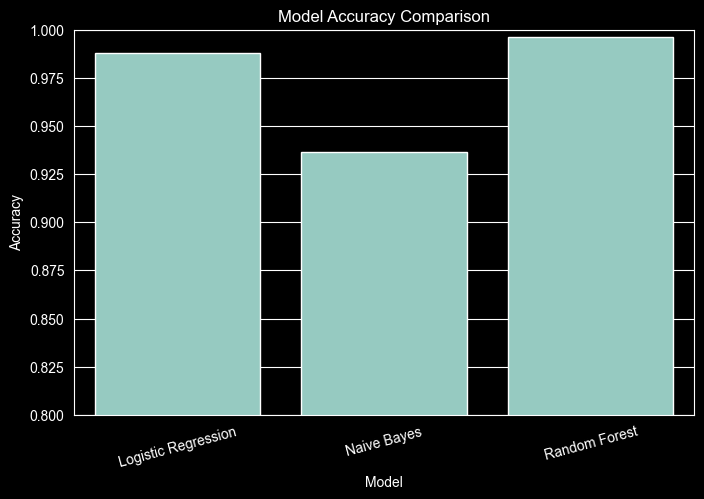

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Accuracy", data=comparison_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.show()

In [21]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, lr_pred))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3536
           1       0.98      0.99      0.99      4285

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



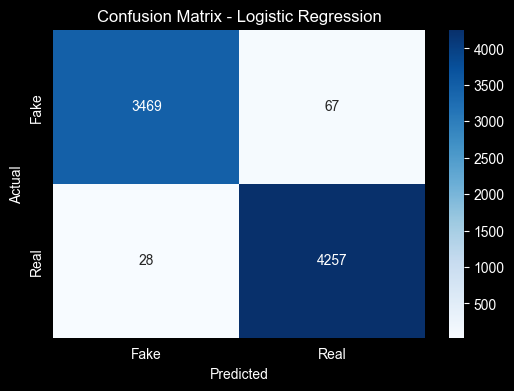

In [22]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
def predict_news(news_text):
    cleaned_text = clean_text(news_text)
    vectorized_text = vectorizer.transform([cleaned_text])
    prediction = lr_model.predict(vectorized_text)[0]

    if prediction == 0:
        return "Fake News"
    else:
        return "Real News"

In [24]:
sample_news = "The government has announced a new education policy to improve digital learning in rural areas."

print("Prediction:", predict_news(sample_news))

Prediction: Fake News


In [27]:
user_news = input("Enter a news article: ")
print("Prediction:", predict_news(user_news))

Prediction: Real News
